In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 92.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time
from torchsummary import summary
from typing import Dict, List, Tuple
import matplotlib.image as mpimg
from tempfile import TemporaryDirectory
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import zipfile
import os

# Create a directory to store the extracted files
os.makedirs('gastrovision_data', exist_ok=True)

# Extract the zip file
with zipfile.ZipFile('/content/drive/MyDrive/Image segmentation/Gastrovision.zip', 'r') as zip_ref:
    zip_ref.extractall('gastrovision_data')

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [ ]:
# Enable CUDA launch blocking for better error messages
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'


In [ ]:
data_dir ='/content/drive/MyDrive/Location'

Training set size: 1627
Validation set size: 407
['Location-Normal stomach', 'Location-Pylorus', 'Location-cardia_normal z-line', 'Location-esophagus']


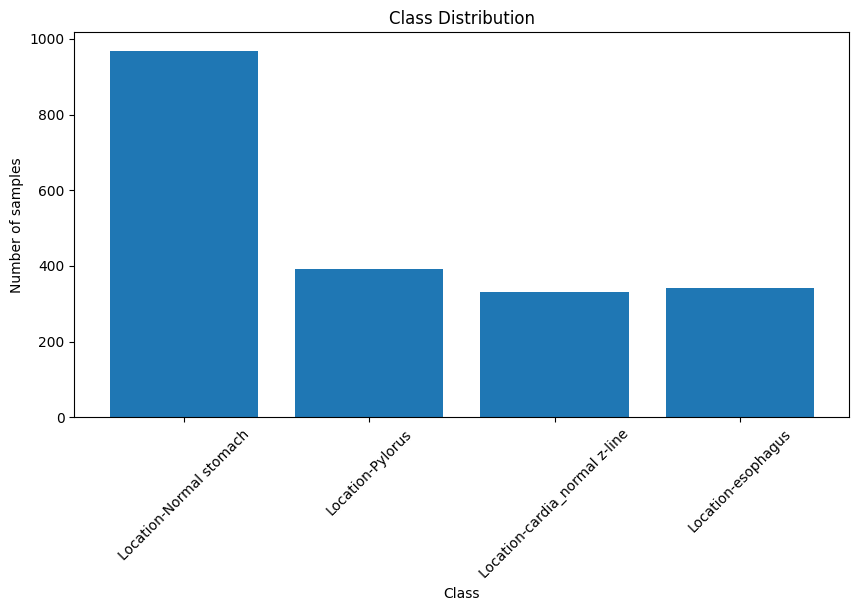

In [ ]:
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

# Load the entire dataset
full_dataset = datasets.ImageFolder(os.path.join(data_dir), data_transforms['train'])

# Define the split ratio
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Split the dataset
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create DataLoaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=16, shuffle=True, num_workers=2)
}

# Get dataset sizes
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = full_dataset.classes

print(f"Training set size: {dataset_sizes['train']}")
print(f"Validation set size: {dataset_sizes['val']}")
print(class_names)

# Count the number of samples for each class
class_counts = np.bincount(full_dataset.targets)
class_indices = np.arange(len(class_counts))

# Plot the class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_indices, class_counts, tick_label=class_names)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()



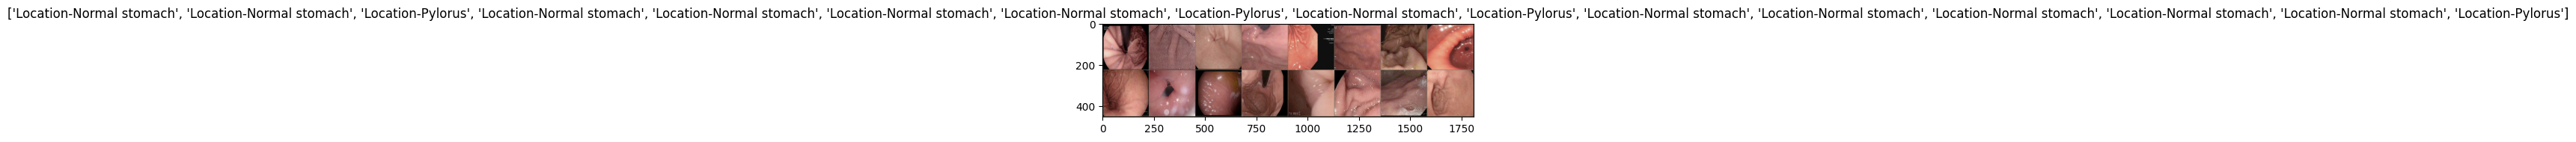

In [ ]:
#visualze a few image
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(dataloaders['train']))

out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=100):
    since = time.time()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in tqdm(dataloaders[phase], desc=f'{phase} Epoch {epoch}/{num_epochs - 1}'):
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()


                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, torch.nn.functional.one_hot(labels, num_classes=4).float())

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'train':
                    train_loss_history.append(epoch_loss)
                    train_acc_history.append(epoch_acc)
                else:
                    val_loss_history.append(epoch_loss)
                    val_acc_history.append(epoch_acc)

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history


In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]} ({probs[j].item()*100:.2f}%)')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


In [ ]:
def plot_training_history(train_loss, val_loss, train_acc, val_acc):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, 'r', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

In [ ]:
model = models.resnet50(weights=False)
model.load_state_dict(torch.load('/content/drive/MyDrive/Transfer learning/RN50_GastroNet-1M_DINOv1.pth', weights_only=True), strict = False)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 4),
    nn.Softmax(dim=1)
)

model = model.to(device)

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 0/99
----------


train Epoch 0/99: 100%|██████████| 102/102 [00:12<00:00,  8.17it/s]


train Loss: 0.1603 Acc: 0.4886


val Epoch 0/99: 100%|██████████| 26/26 [00:03<00:00,  8.36it/s]


val Loss: 0.1482 Acc: 0.5774

Epoch 1/99
----------


...

train Epoch 99/99: 100%|██████████| 102/102 [00:12<00:00,  7.92it/s]


train Loss: 0.0894 Acc: 0.7548


val Epoch 99/99: 100%|██████████| 26/26 [00:03<00:00,  8.12it/s]


val Loss: 0.0966 Acc: 0.7125

Training complete in 25m 57s
Best val Acc: 0.756757


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

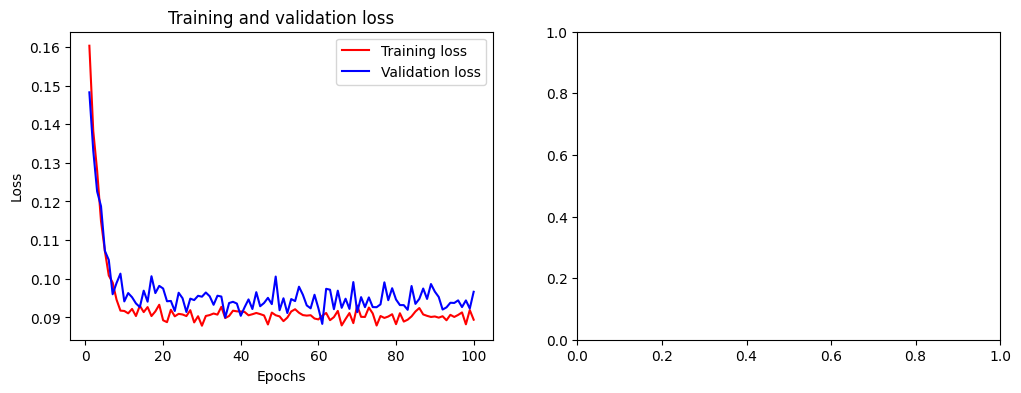

In [ ]:
model_ft, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, criterion, optimizer, scheduler, num_epochs=100)
plot_training_history(train_loss_history, val_loss_history, train_acc_history, val_acc_history)

In [ ]:
import torch.onnx

# Save the trained model for TensorRT
def save_model_for_tensorrt(model, path):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224, device=device)
    torch.onnx.export(model, dummy_input, path, export_params=True, opset_version=11, do_constant_folding=True, input_names=['input'], output_names=['output'])


save_model_for_tensorrt(model_ft, '/content/drive/MyDrive/Transfer learning/Location_model_rt.onnx')

In [ ]:
#save the model
torch.save(model.state_dict(), '/content/drive/MyDrive/Transfer learning/Location_model_2.pth')


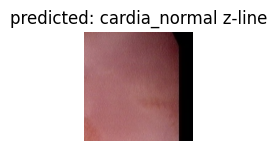

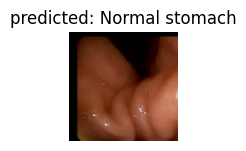

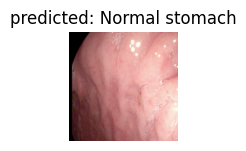

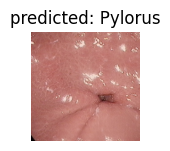

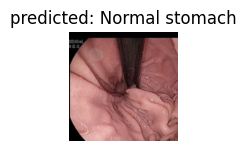

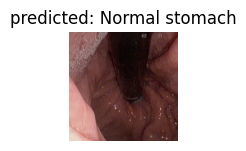

In [ ]:
visualize_model(model)

In [ ]:
def visualize_model_predictions(model, img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path).convert('RGB')
    img = data_transforms['val'](img)  # Apply validation transformation
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2, 2, 1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

    model.train(mode=was_training)

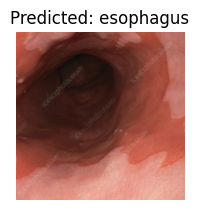

In [ ]:
 visualize_model_predictions(
    model,
    img_path='/content/drive/MyDrive/800wm.jpg'
)